# Part1: FINd Algorithm — Accuracy Evaluation

This part evaluates the Correctness and Perceptual Performance of the **original FINd algorithm** using three standard checks from the image hashing literature.

All the resources and the references are documented in the Report.

---
## 0. Setup

This part includes: Imports, paths, and helper utilities.

Make sure the Image_folder is in the right parth among replication

In [ ]:
import sys
import io
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

sys.path.insert(0, str(Path("../").resolve()))
from FINd import FINDHasher

random.seed(42)
np.random.seed(42)

hasher     = FINDHasher()
MEME_DIR   = Path("../DS in practice TA/Summative /meme_images") #CHANGE THIS TO YOUR MEME IMAGES PATH
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

assert MEME_DIR.exists(), f"Dataset not found: {MEME_DIR}"

all_images = sorted(MEME_DIR.glob("*.jpg"))

def get_family(path):
    return path.name.split("_")[0]

family_map = defaultdict(list)
for p in all_images:
    family_map[get_family(p)].append(p)

print(f"Total images   : {len(all_images):,}")
print(f"Total families : {len(family_map):,}")


Total images   : 55,972
Total families : 1,035


---
## Check 1 — Sanity Check

The first test. A correctly implemented hash must produce identical bits when the same image is hashed twice. The Hamming distance between the two hashes must be exactly zero (this is just re-erification first step, since the test file checked it).



In [3]:
# Hash 20 random images twice each and check the distance is zero every time
test_images  = random.sample(all_images, 20)
sanity_results = []

for img_path in test_images:
    h1 = hasher.fromFile(str(img_path))
    h2 = hasher.fromFile(str(img_path))
    distance = h1 - h2
    sanity_results.append({
        "image"   : img_path.name,
        "distance": distance,
        "pass"    : distance == 0
    })

san_df   = pd.DataFrame(sanity_results)
all_pass = san_df["pass"].all()

print(f"Images tested : {len(san_df)}")
print(f"All distances : {san_df['distance'].unique().tolist()}")
print(f"Result        : {'PASS — all distances are 0' if all_pass else 'FAIL — non-zero distances detected'}")

Images tested : 20
All distances : [0]
Result        : PASS — all distances are 0


---
## Check 2 — Robustness

A robust hash should produce similar hash values when the same image undergoes minor real-world modifications. This check applies a set of standard transformations and reports the resulting Hamming distance between the original and modified hash — no fixed threshold is imposed. Distances close to zero indicate the hash is stable; larger distances indicate sensitivity to that transformation.

I apply the following transformations:
- **JPEG re-compression** at quality levels 90, 70, 50, and 30
- **Resize** to 75% and 50% of the original dimensions
- **Brightness adjustment** at 50% (darker) and 150% (brighter)
- **Gaussian blur** with radius 2

For each transformation we report:
- **Mean Hamming distance** from the original hash
- **Changed rate** — the proportion of images where the hash changed at all (distance > 0)

In [18]:
def apply_transformations(img_path):
    """Apply standard transformations and return {name: PIL.Image}."""
    img = Image.open(img_path).convert("RGB")
    transforms = {}

    for q in [90, 70, 50, 30]:
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        transforms[f"JPEG q={q}"] = Image.open(buf).convert("RGB")

    w, h = img.size
    for scale, label in [(0.75, "Resize 75%"), (0.5, "Resize 50%")]:
        transforms[label] = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)

    transforms["Brightness 50%"]  = ImageEnhance.Brightness(img).enhance(0.5)
    transforms["Brightness 150%"] = ImageEnhance.Brightness(img).enhance(1.5)
    transforms["Gaussian blur"]   = img.filter(ImageFilter.GaussianBlur(radius=2))

    return img, transforms


rob_images  = random.sample(all_images, 10)
rob_records = []

for img_path in rob_images:
    orig_img, transforms = apply_transformations(img_path)
    h_orig = hasher.fromImage(orig_img)
    for t_name, t_img in transforms.items():
        d = hasher.fromImage(t_img) - h_orig
        rob_records.append({"transformation": t_name, "distance": d,
                             "changed": int(d > 0)})

rob_df   = pd.DataFrame(rob_records)
summary2 = rob_df.groupby("transformation").agg(
    mean_distance=("distance", "mean"),
    changed_rate=("changed", "mean")
).round(3).sort_values("mean_distance")
summary2["changed_rate_pct"] = (summary2["changed_rate"] * 100).round(1)

print("Robustness results (10 images):")
print()
print(summary2[["mean_distance", "changed_rate_pct"]].rename(
    columns={"mean_distance": "Mean Hamming Dist", "changed_rate_pct": "Hash Changed (%)"}
).to_string())
summary2.to_csv(OUTPUT_DIR / "check2_robustness.csv")

Robustness results (10 images):

                 Mean Hamming Dist  Hash Changed (%)
transformation                                      
JPEG q=90                      0.0               0.0
Brightness 50%                 0.4              20.0
JPEG q=70                      0.6              20.0
JPEG q=50                      1.6              70.0
JPEG q=30                      2.2              80.0
Gaussian blur                  6.0             100.0
Resize 75%                     8.6             100.0
Resize 50%                    10.4             100.0
Brightness 150%               19.4             100.0


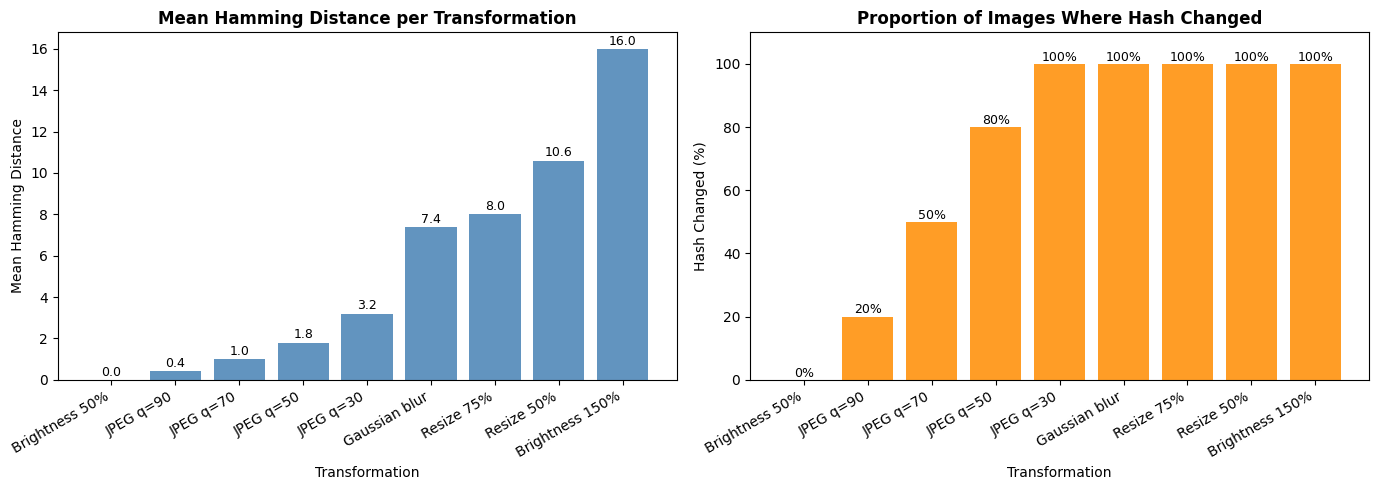

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Hamming distance per transformation
ax1 = axes[0]
bars = ax1.bar(summary2.index, summary2["mean_distance"], color="steelblue", alpha=0.85)
ax1.set_ylabel("Mean Hamming Distance")
ax1.set_xlabel("Transformation")
ax1.set_title("Mean Hamming Distance per Transformation", fontweight="bold")
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")
for bar, val in zip(bars, summary2["mean_distance"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val:.1f}", ha="center", fontsize=9)

# Hash changed rate
ax2 = axes[1]
bars2 = ax2.bar(summary2.index, summary2["changed_rate_pct"], color="darkorange", alpha=0.85)
ax2.set_ylabel("Hash Changed (%)")
ax2.set_xlabel("Transformation")
ax2.set_title("Proportion of Images Where Hash Changed", fontweight="bold")
ax2.set_ylim([0, 110])
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
for bar, val in zip(bars2, summary2["changed_rate_pct"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "check2_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Check 3 — Discrimination

A good hash must not only stay stable for similar images — it must also clearly separate unrelated images. This check measures how well FINd distinguishes between Images.

I build two sets of pairs:
- Same-family pairs: two different images from the same meme family
- Different-familt pairs: two images from different families

I then plot both Hamming distance distributions on the same chart. The further apart the two distributions sit, the more discriminative the hash.


NOTE: results may vary slightly across runs due to random image sampling, but remain representative of the algorithm's overall behaviour.

In [6]:
N_PAIRS = 100  # number of pairs per group

# Same-family pairs: two different images from the same meme family
# These share visual content so their hashes should be closer than random
eligible_families = [f for f, imgs in family_map.items() if len(imgs) >= 2]
dup_dists = []
while len(dup_dists) < N_PAIRS:
    fam  = random.choice(eligible_families)
    p1, p2 = random.sample(family_map[fam], 2)
    dup_dists.append(hasher.fromFile(str(p1)) - hasher.fromFile(str(p2)))

# Non-duplicate pairs: two images from different families
fids = list(family_map.keys())
ndup_dists = []
while len(ndup_dists) < N_PAIRS:
    f1, f2 = random.sample(fids, 2)
    p1 = random.choice(family_map[f1])
    p2 = random.choice(family_map[f2])
    ndup_dists.append(hasher.fromFile(str(p1)) - hasher.fromFile(str(p2)))

print("Same-family pairs (should be closer):")
print(f"  Mean distance : {np.mean(dup_dists):.1f}")
print(f"  Max distance  : {np.max(dup_dists)}")
print()
print("Non-duplicate pairs (different families):")
print(f"  Mean distance  : {np.mean(ndup_dists):.1f}")
print()
print(f"Gap between means: {np.mean(ndup_dists) - np.mean(dup_dists):.1f}")

Same-family pairs (should be closer):
  Mean distance : 55.2
  Max distance  : 126

Non-duplicate pairs (different families):
  Mean distance  : 125.8

Gap between means: 70.7


/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_71347/3042355543.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([dup_dists, ndup_dists], patch_artist=True,


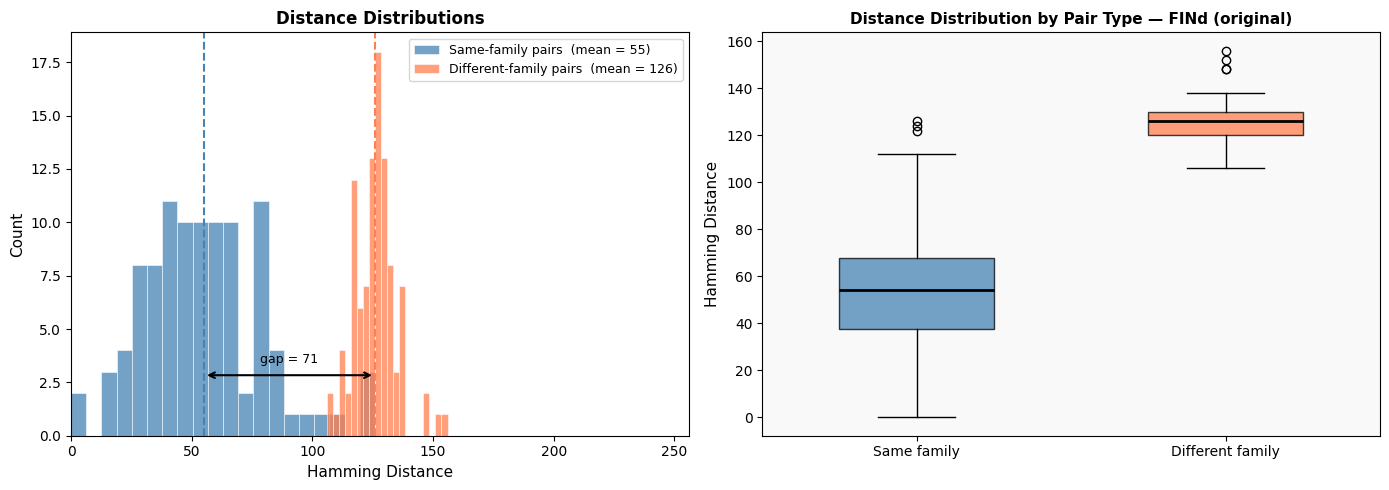

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dup_mean  = np.mean(dup_dists)
ndup_mean = np.mean(ndup_dists)

# --- Histogram ---
ax = axes[0]
ax.hist(dup_dists,  bins=20, alpha=0.75, color="steelblue",
        label=f"Same-family pairs  (mean = {dup_mean:.0f})", edgecolor="white", linewidth=0.5)
ax.hist(ndup_dists, bins=20, alpha=0.75, color="coral",
        label=f"Different-family pairs  (mean = {ndup_mean:.0f})", edgecolor="white", linewidth=0.5)
ax.axvline(dup_mean,  color="steelblue", linestyle="--", lw=1.5)
ax.axvline(ndup_mean, color="coral",     linestyle="--", lw=1.5)
ax.set_xlim(0, 256)
ax.set_xlabel("Hamming Distance", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Distance Distributions", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
y_top = ax.get_ylim()[1]
ax.annotate("", xy=(ndup_mean, y_top * 0.15), xytext=(dup_mean, y_top * 0.15),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text((dup_mean + ndup_mean) / 2, y_top * 0.18,
        f"gap = {ndup_mean - dup_mean:.0f}", ha="center", fontsize=9)

# --- Box plot: auto-scaled ---
ax2 = axes[1]
bp = ax2.boxplot([dup_dists, ndup_dists], patch_artist=True,
                  labels=["Same family", "Different family"],
                  widths=0.5, medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], ["steelblue", "coral"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_ylabel("Hamming Distance", fontsize=11)
ax2.set_title("Distance Distribution by Pair Type — FINd (original)",
              fontweight="bold", fontsize=11)
ax2.set_facecolor("#f9f9f9")


plt.tight_layout()
plt.savefig(OUTPUT_DIR / "check3_discrimination.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Check 4 — Precision, Recall, F1

The previous checks show the distance distributions qualitatively. This check turns FINd into a binary classifier and measures its quantitative performance.

For differnet threshold: if the Hamming distance between two images is below the threshold, I predict they are duplicates. I then compute:

- **Precision** — of all pairs the algorithm called duplicates, what fraction actually were?
- **Recall** — of all actual duplicate pairs, what fraction did the algorithm find?
- **F1** — harmonic mean of precision and recall; a single summary score

I sweep every threshold from 0 to 256 and report the metrics at the threshold that maximises F1. 

In [8]:
distances = np.array(dup_dists + ndup_dists)
labels    = np.array([1]*len(dup_dists) + [0]*len(ndup_dists))  # 1=duplicate

results_c = []
for t in range(0, 257):
    pred = (distances < t).astype(int)
    tp   = int(((pred==1) & (labels==1)).sum())
    fp   = int(((pred==1) & (labels==0)).sum())
    fn   = int(((pred==0) & (labels==1)).sum())
    p    = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    r    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1   = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    results_c.append({"threshold": t, "precision": p, "recall": r, "f1": f1})

thresh_df = pd.DataFrame(results_c)
best      = thresh_df.loc[thresh_df["f1"].idxmax()]

print("Best threshold (maximises F1):")
print(f"  Threshold : {int(best['threshold'])}")
print(f"  Precision : {best['precision']:.4f}")
print(f"  Recall    : {best['recall']:.4f}")
print(f"  F1        : {best['f1']:.4f}")

thresh_df.to_csv(OUTPUT_DIR / "check4_prf_by_threshold.csv", index=False)

Best threshold (maximises F1):
  Threshold : 107
  Precision : 0.9897
  Recall    : 0.9600
  F1        : 0.9746


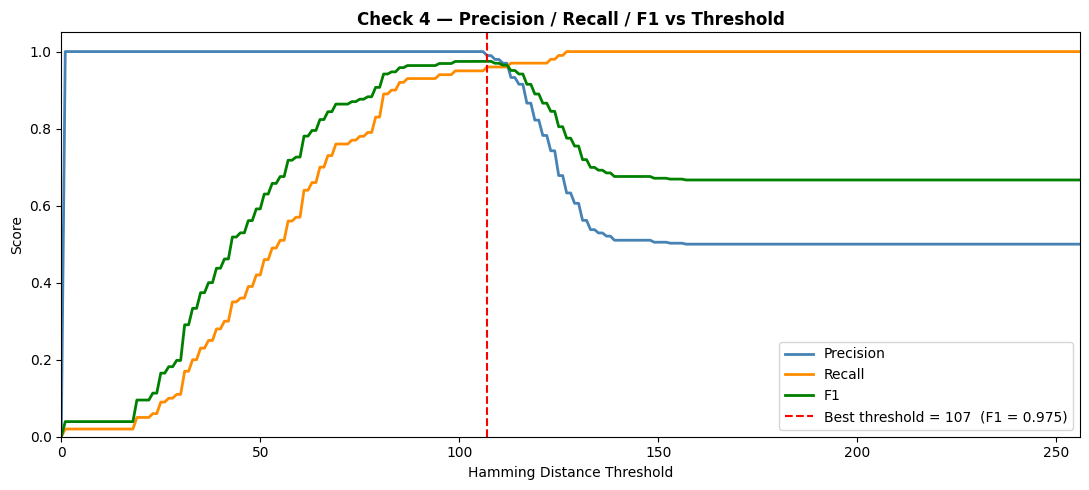

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"],
        color="steelblue",  lw=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["recall"],
        color="darkorange", lw=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["f1"],
        color="green",      lw=2, label="F1")
ax.axvline(best["threshold"], color="red", linestyle="--", lw=1.5,
           label=f"Best threshold = {int(best['threshold'])}  "
                 f"(F1 = {best['f1']:.3f})")
ax.set_xlabel("Hamming Distance Threshold")
ax.set_ylabel("Score")
ax.set_title("Check 4 — Precision / Recall / F1 vs Threshold",
             fontweight="bold")
ax.set_xlim([0, 256])
ax.set_ylim([0, 1.05])
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "check4_prf.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part 2 — Computational Performance

After checking the correctness of the algorithm output and assessing its performace, I evaluate its computational cost through the following:

| What to measure | Tool | What it tells us |
|---|---|---|
| Wall-clock runtime | `timeit.repeat` | mean ± std (ms) per image |
| CPU time | `time.process_time` | actual CPU cycles used (ms) |
| CPU utilisation | `psutil.Process.cpu_percent` | % of one core per hash call |
| Peak memory | `tracemalloc` | peak MB per image |
| Scaling — runtime, CPU & memory | `timeit` + `process_time` + `tracemalloc` across N | how all three grow with N = 10, 50, 100, 500, 1,000 |
| Function bottleneck | `cProfile` | top functions by cumtime |
| Line bottleneck | `line_profiler` | % time per line |

The bottleneck identified in the final two steps directly motivates the optimisation in the next section.

In [19]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [20]:
import timeit
import statistics

# 1.Runtime per image 
# repeat=10 runs, number=1 execution per run 
sample_images = random.sample(all_images, 20)
timings_ms = []

for img_path in sample_images:
    times = timeit.repeat(
        stmt=lambda: hasher.fromFile(str(img_path)),
        repeat=10,
        number=1
    )
    timings_ms.append(min(times) * 1000)   # minimum of repeats, in ms

mean_ms   = statistics.mean(timings_ms)
median_ms = statistics.median(timings_ms)
std_ms    = statistics.stdev(timings_ms)

print("Runtime per image (20 images, min of 10 repeats each):")
print(f"  Mean   : {mean_ms:.1f} ms")
print(f"  Median : {median_ms:.1f} ms")
print(f"  Std    : {std_ms:.1f} ms")


Runtime per image (20 images, min of 10 repeats each):
  Mean   : 108.5 ms
  Median : 109.7 ms
  Std    : 5.6 ms


In [21]:
# 2.CPU time (time.process_time) 
# process_time counts actual CPU cycles 

import time, statistics

sample_cpu = random.sample(all_images, 20)
cpu_timings_ms = []

for img_path in sample_cpu:
    runs = []
    for _ in range(10):
        t0 = time.process_time()
        hasher.fromFile(str(img_path))
        runs.append((time.process_time() - t0) * 1000)
    cpu_timings_ms.append(min(runs))

cpu_mean = statistics.mean(cpu_timings_ms)
cpu_std  = statistics.stdev(cpu_timings_ms)
print('CPU time per image (20 images, min of 10 repeats each):')
print(f'  Mean : {cpu_mean:.1f} ms')
print(f'  Std  : {cpu_std:.1f} ms')
print(f'  Reported as: {cpu_mean:.1f} ± {cpu_std:.1f} ms')

CPU time per image (20 images, min of 10 repeats each):
  Mean : 107.0 ms
  Std  : 15.2 ms
  Reported as: 107.0 ± 15.2 ms


In [22]:
# 3.CPU utilisation 
# cpu_percent measures what fraction of one CPU core this process used

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'psutil', '-q'])
import psutil, os

proc = psutil.Process(os.getpid())
proc.cpu_percent()  # warm-up: discard first reading

img_path = str(random.choice(all_images))
cpu_readings = []

for _ in range(20):
    proc.cpu_percent()
    hasher.fromFile(img_path)
    cpu_readings.append(proc.cpu_percent())

cpu_util_mean = statistics.mean(cpu_readings)
cpu_util_std  = statistics.stdev(cpu_readings)
print('CPU utilisation per hash call (20 readings):')
print(f'  Mean : {cpu_util_mean:.1f}%')
print(f'  Std  : {cpu_util_std:.1f}%')
print(f'  Reported as: {cpu_util_mean:.1f} ± {cpu_util_std:.1f}% of one core')

CPU utilisation per hash call (20 readings):
  Mean : 99.9%
  Std  : 0.3%
  Reported as: 99.9 ± 0.3% of one core


In [13]:
# 4.Memory usage per image (tracemalloc) 
# tracemalloc is Python's built-in memory tracer (works on all versions)
# peak = highest memory allocated during the call

import tracemalloc
import statistics as _stats

mem_peaks = []
for p in random.sample(all_images, 20):
    tracemalloc.start()
    hasher.fromFile(str(p))
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    mem_peaks.append(peak / 1024)  # bytes -> KB

print('Peak memory per image (20 images):')
print(f'  Mean   : {_stats.mean(mem_peaks):.1f} KB')
print(f'  Median : {_stats.median(mem_peaks):.1f} KB')
print(f'  Max    : {max(mem_peaks):.1f} KB')

Peak memory per image (20 images):
  Mean   : 3829.2 KB
  Median : 3989.7 KB
  Max    : 3994.6 KB


In [23]:
import time, tracemalloc, timeit, statistics

# Scaling analysis: runtime, CPU time, and memory across dataset sizes -
sizes = [10, 50, 100, 500, 1000]
scaling_records = []

for n in sizes:
    sample = random.sample(all_images, n)

    # Wall-clock runtime (minimum of 3 repetitions)
    wall_times = timeit.repeat(
        stmt=lambda: [hasher.fromFile(str(p)) for p in sample],
        repeat=3, number=1
    )
    wall_time = min(wall_times)

    # CPU time (process_time excludes I/O waits)
    cpu_start = time.process_time()
    for p in sample:
        hasher.fromFile(str(p))
    cpu_time = time.process_time() - cpu_start

    # Peak memory (tracemalloc)
    tracemalloc.start()
    for p in sample:
        hasher.fromFile(str(p))
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    scaling_records.append({
        "N"              : n,
        "wall_time_s"    : wall_time,
        "cpu_time_s"     : cpu_time,
        "peak_memory_MB" : peak_mem / (1024**2),
        "wall_per_img_ms": wall_time / n * 1000,
        "cpu_per_img_ms" : cpu_time  / n * 1000,
    })

scaling_df = pd.DataFrame(scaling_records)
print(scaling_df.round(3).to_string(index=False))
scaling_df.to_csv(OUTPUT_DIR / "step2_scaling_all.csv", index=False)

   N  wall_time_s  cpu_time_s  peak_memory_MB  wall_per_img_ms  cpu_per_img_ms
  10        1.121       1.122           3.905          112.075         112.164
  50        5.375       5.447           3.905          107.507         108.939
 100       10.654      10.739           3.905          106.544         107.390
 500       53.566      54.931           3.907          107.132         109.862
1000      108.883     110.401           3.907          108.883         110.401


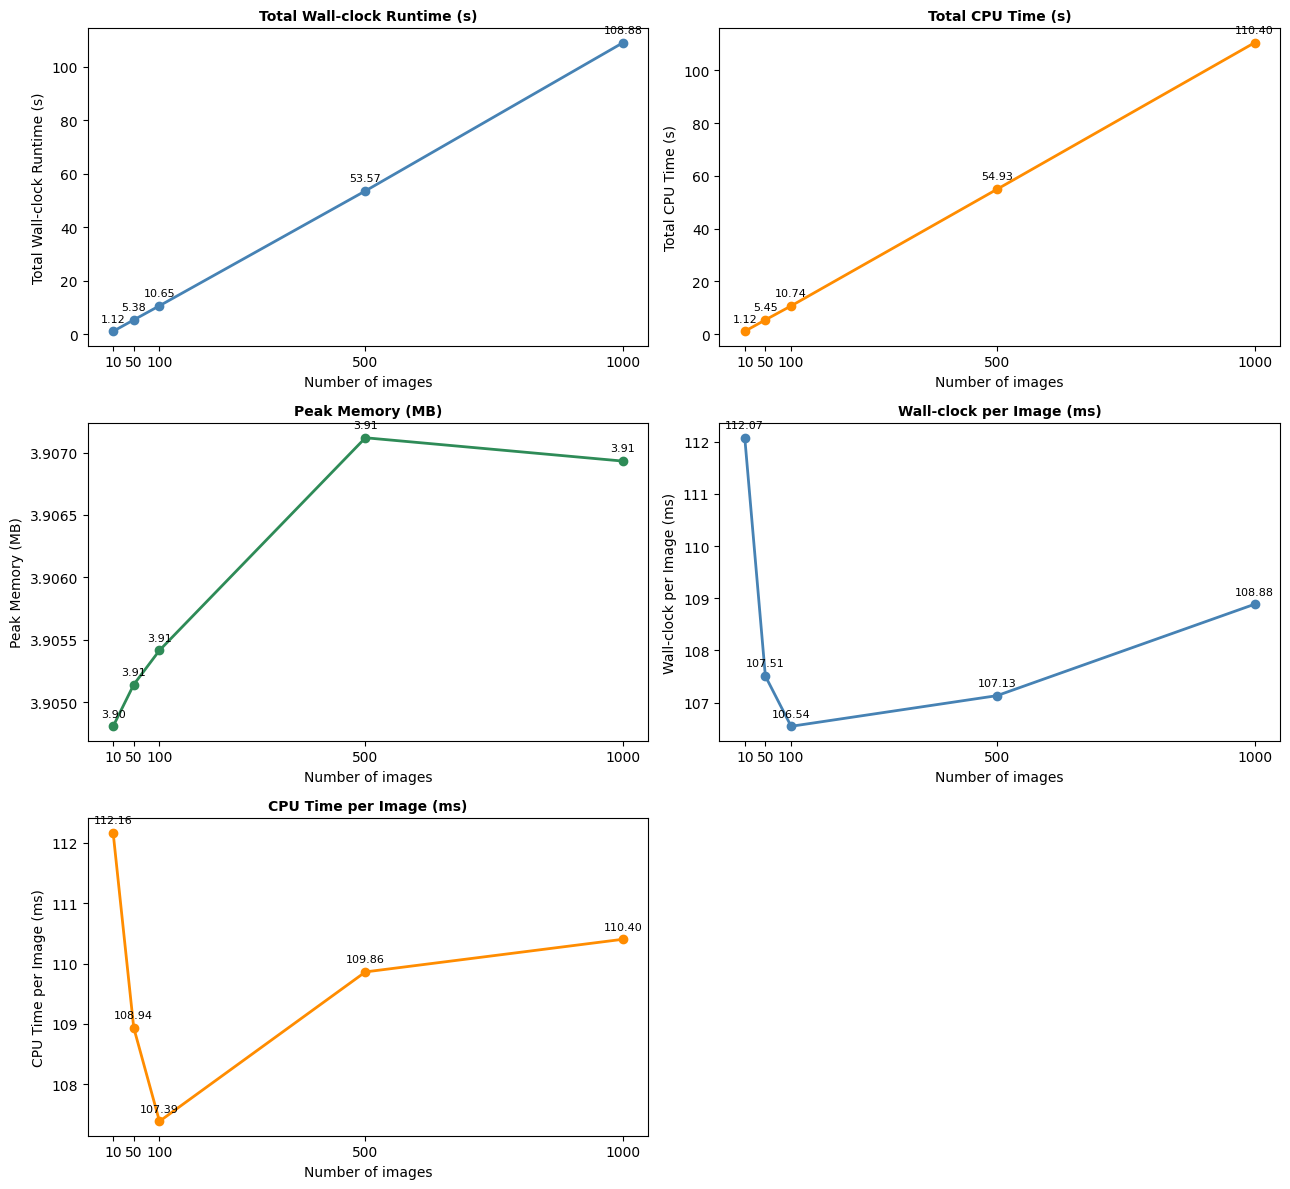

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))

metrics = [
    ("wall_time_s",     "Total Wall-clock Runtime (s)",  "steelblue"),
    ("cpu_time_s",      "Total CPU Time (s)",            "darkorange"),
    ("peak_memory_MB",  "Peak Memory (MB)",              "seagreen"),
    ("wall_per_img_ms", "Wall-clock per Image (ms)",     "steelblue"),
    ("cpu_per_img_ms",  "CPU Time per Image (ms)",       "darkorange"),
]

for ax, (col, ylabel, color) in zip(axes.flat, metrics):
    ax.plot(scaling_df['N'], scaling_df[col], marker='o', color=color, lw=2)
    ax.set_xlabel('Number of images', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontweight='bold', fontsize=10)
    ax.set_xticks(sizes)
    for x, y in zip(scaling_df['N'], scaling_df[col]):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=8)

axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import cProfile, pstats, io

# 5.cProfile — function-level breakdown ---
img_path = str(random.choice(all_images))
pr = cProfile.Profile()
pr.enable()
for _ in range(10):
    hasher.fromFile(img_path)
pr.disable()

stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats("cumulative")
ps.print_stats(12)
print(stream.getvalue())

         8128390 function calls (8128384 primitive calls) in 1.970 seconds

   Ordered by: cumulative time
   List reduced from 213 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    1.969    0.984 /opt/anaconda3/envs/FSDS/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3663(run_code)
      3/2    0.000    0.000    1.969    0.984 {built-in method builtins.exec}
        1    0.002    0.002    1.969    1.969 /var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_57354/3861724944.py:1(<module>)
       10    0.006    0.001    1.958    0.196 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:39(fromFile)
       10    0.000    0.000    1.951    0.195 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:47(fromImage)
       10    0.000    0.000    1.247    0.125 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py:79(findHash256FromFloatL

In [ ]:
# 6.line_profiler — line-level breakdown of the bottleneck functions ---
%lprun -f hasher.fromImage \
       -f hasher.fillFloatLumaFromBufferImage \
       -f hasher.boxFilter \
       -f hasher.dct64To16 \
       hasher.fromFile(str(random.choice(all_images)))

Timer unit: 1e-09 s

Total time: 2.16621 s
File: /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd.py
Function: FINDHasher.fromImage at line 47

Line #      Hits         Time  Per Hit   % Time  Line Contents
    47                                           	def fromImage(self,img):
    48         1       4000.0   4000.0      0.0  		try:
    49                                           			# resizing the image proportionally to max 512px width and max 512px height
    50         1     447000.0 447000.0      0.0  			img=img.copy()
    51         1      17000.0  17000.0      0.0  			img.thumbnail((512, 512)) #https://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail
    52                                           		except IOError as e:
    53                                           			raise e
    54         1       1000.0   1000.0      0.0  		numCols, numRows = img.size
    55         1      12000.0  12000.0      0.0  		buffer1 = MatrixUtil.